# Lecture 6 - Finite Interventions and Path-based Explanations

In [7]:
# =========================
# CELL 0 — shared setup (reusable)
# =========================
# Seeds, device selection, filepaths, and MNIST loaders.

import random
import numpy as np
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# -----------------------
# Reproducibility + device
# -----------------------
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(0)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

# -----------------------
# Paths
# -----------------------
DATA_DIR = Path("../../datasets/mnist")
WEIGHTS_PATH = Path("runs_mnist") / "mnist_cnn.pt"

# Output directory for figures (used in Cell 2)
FIGDIR = Path("./figures6")
FIGDIR.mkdir(parents=True, exist_ok=True)

# -----------------------
# Data
# -----------------------
BATCH_SIZE = 256

transform = transforms.Compose([
    transforms.ToTensor(),   # keep raw pixels in [0,1]
])

test_ds = datasets.MNIST(
    root=str(DATA_DIR),
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ------------------------------------------------------------------------
# Integrated Gradients (straight-line path) with cumulative partial maps.
# ------------------------------------------------------------------------
def integrated_gradients_with_partials(model, x0, x1, target_class, steps=64, device=None):
    """
    Integrated Gradients from x0 -> x1 along the straight-line path.
    Returns:
      ts_cpu:      (steps+1,)
      xts_cpu:     (steps+1, C, H, W)  intermediate inputs
      partial_ig:  (steps+1, C, H, W)  cumulative IG up to each grid point
      ig_final:    (H, W)              final IG map for channel 0 (MNIST)
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()

    x0 = x0.to(device)
    x1 = x1.to(device)

    delta = x1 - x0
    ts = torch.linspace(0.0, 1.0, steps + 1, device=device)
    dt = 1.0 / steps

    partial_int = torch.zeros_like(x0, device=device)
    xt_list = []
    partial_list = []

    for t in ts:
        xt = (x0 + t * delta).detach().requires_grad_(True)
        score = model(xt)[0, target_class]
        grad = torch.autograd.grad(score, xt, retain_graph=False, create_graph=False)[0].detach()

        partial_int = partial_int + grad * dt
        xt_list.append(xt.detach())
        partial_list.append((delta * partial_int).detach())

    xts = torch.cat(xt_list, dim=0).detach().cpu()
    partial_ig = torch.cat(partial_list, dim=0).detach().cpu()
    ts_cpu = ts.detach().cpu()
    ig_final = partial_ig[-1, 0].detach().cpu()  # (H,W) for MNIST channel 0

    return ts_cpu, xts, partial_ig, ig_final

print("Loaded MNIST test split:", len(test_ds), "examples")
print("Weights path:", WEIGHTS_PATH.resolve())
print("Figure dir:", FIGDIR.resolve())

Device: cuda
Loaded MNIST test split: 10000 examples
Weights path: /home/rwhite/Documents/Spring-2026-Explainable-AI/lectures/runs_mnist/mnist_cnn.pt
Figure dir: /home/rwhite/Documents/Spring-2026-Explainable-AI/lectures/figures6


In [19]:
# =========================
# CELL 1 — work cell (hyperparameters + computation)
# =========================
# Loads model, selects a single MNIST test image of digit=HP["digit"],
# computes Integrated Gradients from zero baseline to the selected image,
# and stores a RESULTS dict for Cell 2.

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------
# Hyperparameters
# -----------------------
HP = {
    "digit": 8,
    "pick": "first_correct",          # "first", "first_correct", or "max_conf_correct"
    "ig_steps": 96,
    "target_class": 1,                # scalarization: logit for this class
    "display_t": np.linspace(0.0, 1.0, 9),
}

# -----------------------
# Model (must match saved weights)
# -----------------------
class SmallMNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool2(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = SmallMNISTCNN().to(device)
state = torch.load(WEIGHTS_PATH, map_location="cpu")
model.load_state_dict(state)
model.eval()

@torch.no_grad()
def logits_and_probs(x):
    logits = model(x.to(device))
    probs = torch.softmax(logits, dim=1)
    return logits.detach().cpu(), probs.detach().cpu()

@torch.no_grad()
def predict_class(x):
    logits = model(x.to(device))
    return int(torch.argmax(logits, dim=1).item())

@torch.no_grad()
def class_confidence(x, cls):
    _, probs = logits_and_probs(x)
    return float(probs[0, cls].item())

# -----------------------
# Pick a single example from the test set
# -----------------------
def pick_example_from_loader(loader, digit, pick_mode="first_correct"):
    best = None
    best_conf = -1.0
    best_meta = None

    for xb, yb in loader:
        m = (yb == digit)
        if not m.any():
            continue

        X = xb[m]
        Y = yb[m]

        if pick_mode == "first":
            x = X[0:1].cpu()
            y = int(Y[0].item())
            return x, y, {"mode": "first"}

        logits, probs = logits_and_probs(X.to(device))
        pred = torch.argmax(probs, dim=1)

        if pick_mode == "first_correct":
            ok = (pred.cpu() == Y)
            if ok.any():
                j = int(torch.where(ok)[0][0].item())
                x = X[j:j+1].cpu()
                y = int(Y[j].item())
                conf = float(probs[j, digit].item())
                return x, y, {"mode": "first_correct", "conf": conf}

        if pick_mode == "max_conf_correct":
            ok = (pred.cpu() == Y)
            if ok.any():
                idxs = torch.where(ok)[0].cpu().numpy().tolist()
                for j in idxs:
                    conf = float(probs[j, digit].item())
                    if conf > best_conf:
                        best_conf = conf
                        best = X[j:j+1].cpu()
                        best_meta = {"mode": "max_conf_correct", "conf": conf}
                        best_y = int(Y[j].item())

    if best is None:
        raise RuntimeError(f"No suitable example found for digit={digit} with pick_mode={pick_mode}.")
    return best, best_y, best_meta

x, y, meta = pick_example_from_loader(test_loader, HP["digit"], pick_mode=HP["pick"])

x0 = torch.zeros_like(x)     # zero (black) baseline
x1 = x                       # selected digit image

pred_x = predict_class(x1)
conf_target = class_confidence(x1, HP["target_class"])
conf_pred = class_confidence(x1, pred_x)

# -----------------------
# Integrated Gradients (uses helper from Cell 0)
# -----------------------
ts_grid, xts, partial_ig, ig_final = integrated_gradients_with_partials(
    model,
    x0=x0,
    x1=x1,
    target_class=HP["target_class"],
    steps=HP["ig_steps"],
    device=device,
)

ts_np = ts_grid.numpy()
disp_idx = [int(np.argmin(np.abs(ts_np - t))) for t in HP["display_t"]]
disp_idx = sorted(set(disp_idx))
disp_t = ts_np[disp_idx]

RESULTS = {
    "HP": HP,
    "x0": x0,
    "x1": x1,
    "y_true": y,
    "pred_x": pred_x,
    "conf_target": conf_target,
    "conf_pred": conf_pred,
    "pick_meta": meta,
    "ts_grid": ts_grid,
    "xts": xts,
    "partial_ig": partial_ig,
    "ig_final": ig_final,
    "disp_idx": disp_idx,
    "disp_t": disp_t,
}

print("Selected digit (true):", y, " predicted:", pred_x, " pick:", meta)
print("Target class:", HP["target_class"], " P(target) =", f"{conf_target:.3f}")
print("P(pred) =", f"{conf_pred:.3f}")
print("Display t:", disp_t)


Selected digit (true): 8  predicted: 8  pick: {'mode': 'first_correct', 'conf': 0.9999935626983643}
Target class: 1  P(target) = 0.000
P(pred) = 1.000
Display t: [0.    0.125 0.25  0.375 0.5   0.625 0.75  0.875 1.   ]


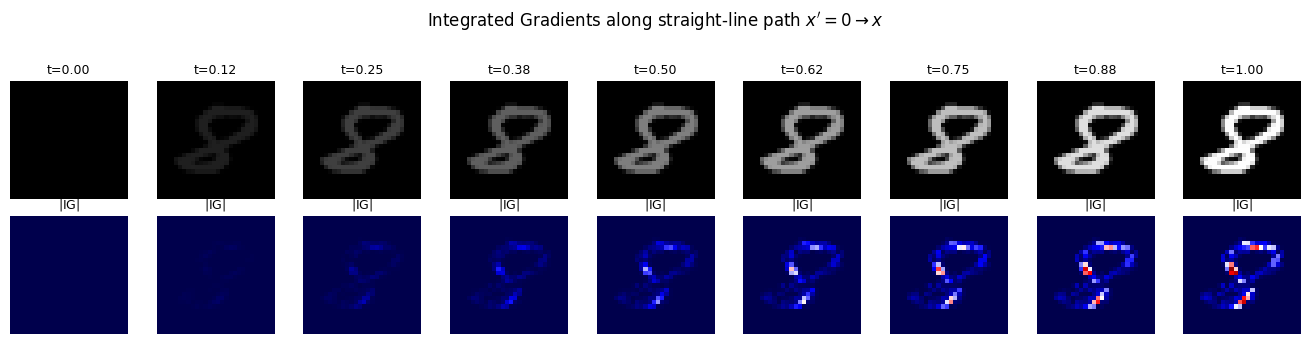

Saved PDFs to: /home/rwhite/Documents/Spring-2026-Explainable-AI/lectures/figures6
  fig_ig_zero_to_digit_endpoints.pdf
  fig_path_and_partial_ig_grid.pdf


In [21]:
# =========================
# CELL 2 — plotting only
# =========================

import numpy as np
import matplotlib.pyplot as plt

HP = RESULTS["HP"]

x0 = RESULTS["x0"]
x1 = RESULTS["x1"]

xts = RESULTS["xts"]                 # (steps+1,1,28,28)
partial_ig = RESULTS["partial_ig"]   # (steps+1,1,28,28)
disp_idx = RESULTS["disp_idx"]
disp_t = RESULTS["disp_t"]

# -----------------------------
# FIG 1: intermediate images + partial |IG|
# -----------------------------
K = len(disp_idx)
fig, axes = plt.subplots(2, K, figsize=(1.35 * K + 1.2, 3.3))

if K == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for j, (idx, tval) in enumerate(zip(disp_idx, disp_t)):
    x_img = xts[idx, 0].numpy()
    ig_abs = np.abs(partial_ig[idx, 0].numpy())

    axes[0, j].imshow(x_img, cmap="gray", vmin=0.0, vmax=1.0)
    axes[0, j].set_title(f"t={tval:.2f}", fontsize=9)
    axes[0, j].axis("off")

    axes[1, j].imshow(ig_abs, cmap="seismic", vmin=0.0, vmax=1.0)
    axes[1, j].set_title(r"$|\mathrm{IG}|$", fontsize=9)
    axes[1, j].axis("off")

fig.suptitle(
    r"Integrated Gradients along straight-line path $x'=0 \rightarrow x$",
    y=1.03,
)

fig.tight_layout()
fig.savefig(FIGDIR / "fig_path_and_partial_ig_grid.pdf", bbox_inches="tight")
plt.show()

print("Saved PDFs to:", FIGDIR.resolve())
print("  fig_ig_zero_to_digit_endpoints.pdf")
print("  fig_path_and_partial_ig_grid.pdf")

In [17]:
# =========================
# CELL 1 — t-SNE full test set, farthest pair of ones, sample along AB, IG(0 -> x)
# =========================

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

# -----------------------
# Hyperparameters (only non-default choices)
# -----------------------
HP = {
    "digit": 1,
    "tsne_max_n": None,        # None uses full test set (10k)
    "n_path_points": 13,       # number of images sampled along AB in t-SNE space
    "ig_steps": 64,            # IG steps per image
    "target_class": 1,         # logit target for IG
}

# -----------------------
# Model (must match saved weights)
# -----------------------
class SmallMNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool2(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = SmallMNISTCNN().to(device)
state = torch.load(WEIGHTS_PATH, map_location="cpu")
model.load_state_dict(state)
model.eval()

@torch.no_grad()
def predict_class_batch(xb):
    logits = model(xb.to(device))
    return torch.argmax(logits, dim=1).detach().cpu()

# -----------------------
# Collect full test set into tensors
# -----------------------
def collect_all_from_loader(loader):
    xs, ys = [], []
    for xb, yb in loader:
        xs.append(xb.cpu())
        ys.append(yb.cpu())
    X = torch.cat(xs, dim=0)  # (N,1,28,28)
    y = torch.cat(ys, dim=0)  # (N,)
    return X, y

X_all, y_all = collect_all_from_loader(test_loader)

# Optional subsample for t-SNE speed (keeps alignment)
if HP["tsne_max_n"] is not None and X_all.shape[0] > HP["tsne_max_n"]:
    rng = np.random.RandomState(0)
    idx = rng.choice(X_all.shape[0], size=HP["tsne_max_n"], replace=False)
    idx = np.sort(idx)
    X_all = X_all[idx]
    y_all = y_all[idx]

N = X_all.shape[0]
print("Test set size used for t-SNE:", N)

# -----------------------
# t-SNE on full test set (2D)
# -----------------------
X_flat = X_all.reshape(N, -1).numpy()
Xz = StandardScaler(with_mean=True, with_std=True).fit_transform(X_flat)
Z_all = TSNE(n_components=2, init="pca", random_state=0, verbose=1).fit_transform(Xz)  # (N,2)

# -----------------------
# Extract the digit subset in t-SNE space
# -----------------------
digit = HP["digit"]
mask_digit = (y_all.numpy() == digit)
Z_d = Z_all[mask_digit]             # (Nd,2)
X_d = X_all[mask_digit]             # (Nd,1,28,28)
Nd = Z_d.shape[0]
print(f"Digit={digit} count in set:", Nd)

# Optional: keep only correctly predicted digit examples (helps remove weird shapes)
pred_d = predict_class_batch(X_d)
keep_correct = (pred_d.numpy() == digit)
Z_d = Z_d[keep_correct]
X_d = X_d[keep_correct]
Nd = Z_d.shape[0]
print(f"Digit={digit} kept (correctly classified):", Nd)

# -----------------------
# Farthest pair in Euclidean distance (t-SNE space) among digit points
# -----------------------
def farthest_pair_two_pass(Z2):
    rng = np.random.RandomState(0)
    i0 = int(rng.randint(0, Z2.shape[0]))
    d0 = np.sum((Z2 - Z2[i0]) ** 2, axis=1)
    ia = int(np.argmax(d0))
    da = np.sum((Z2 - Z2[ia]) ** 2, axis=1)
    ib = int(np.argmax(da))
    return ia, ib, float(np.sqrt(da[ib]))

ia, ib, dist_ab = farthest_pair_two_pass(Z_d)
A = Z_d[ia]
B = Z_d[ib]
print("Endpoint distance in t-SNE space:", dist_ab)

# -----------------------
# Sample points along the segment A->B, then snap to nearest digit point in t-SNE space
# -----------------------
ts = np.linspace(0.0, 1.0, HP["n_path_points"])
P = (1.0 - ts)[:, None] * A[None, :] + ts[:, None] * B[None, :]   # (m,2)

nn = NearestNeighbors(n_neighbors=1).fit(Z_d)
d_near, idx_near = nn.kneighbors(P)
idx_near = idx_near[:, 0]   # indices into Z_d / X_d
d_near = d_near[:, 0]

# Deduplicate while preserving order (nearest snaps can repeat)
idx_path = []
seen = set()
for j in idx_near.tolist():
    if j not in seen:
        idx_path.append(int(j))
        seen.add(int(j))
idx_path = np.array(idx_path, dtype=int)

Z_path = Z_d[idx_path]       # (T,2)
X_path = X_d[idx_path]       # (T,1,28,28)

print("Requested samples:", HP["n_path_points"], "| unique snapped points:", len(idx_path))

# -----------------------
# Compute IG(0 -> x) for each image in the snapped sequence
# -----------------------
x0 = torch.zeros_like(X_path[0:1])  # baseline fixed (black)

imgs = []
ig_maps = []

for i in range(X_path.shape[0]):
    x = X_path[i:i+1]
    _, _, _, ig_final = integrated_gradients_with_partials(
        model, x0=x0, x1=x, target_class=HP["target_class"], steps=HP["ig_steps"], device=device
    )
    imgs.append(x[0, 0].numpy())
    ig_maps.append(ig_final.numpy())

imgs = np.stack(imgs, axis=0)       # (T,28,28)
ig_maps = np.stack(ig_maps, axis=0) # (T,28,28)

RESULTS = {
    "HP": HP,
    "Z_all": Z_all,
    "y_all": y_all.numpy(),
    "Z_d": Z_d,
    "idx_path": idx_path,
    "Z_path": Z_path,
    "A": A,
    "B": B,
    "ia": ia,
    "ib": ib,
    "dist_ab": dist_ab,
    "ts": ts,
    "P": P,
    "snap_dists": d_near,
    "imgs_path": imgs,
    "ig_path": ig_maps,
}

print("Done. RESULTS ready for plotting.")


Test set size used for t-SNE: 10000
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...
[t-SNE] Computed neighbors for 10000 samples in 2.479s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 5.680904
[t-SNE] KL divergence after 250 iterations with early exaggeration: 88.473404
[t-SNE] KL divergence after 1000 iterations